# CNN Image Classification with PyTorch — FashionMNIST
**Student ID:** `220129`

In [29]:

REPO_URL = "https://github.com/kashfihs/220129_CNN.git"
STUDENT_ID = "220129"
REPO_DIR = "220129_CNN"


In [30]:
import os, subprocess, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import confusion_matrix

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 1. Clone Your GitHub Repo (Automatic Data Retrieval)
This pulls your 10 custom phone images from `dataset/` inside your repo. No manual upload needed.

If the repo hasn't been set up yet (or cloning fails), the notebook automatically generates 10 placeholder
images so the rest of the pipeline still runs end-to-end — **but you must replace this with your real
repo + real photos before submission**, or you will lose automation points.


In [31]:
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

dataset_dir = os.path.join(REPO_DIR, "dataset")
model_dir = os.path.join(REPO_DIR, "model")

# Remove old cloned repo so Run All always gets the latest GitHub files
if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

# Clone GitHub repository
result = subprocess.run(
    ["git", "clone", REPO_URL, REPO_DIR],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

# Stop if cloning failed
if result.returncode != 0:
    raise RuntimeError(
        "GitHub clone failed. Check REPO_URL and make sure the repository is public."
    )

# Check dataset folder
if not os.path.isdir(dataset_dir):
    raise FileNotFoundError(
        "dataset/ folder was not found in the GitHub repository."
    )

# Find custom images only
custom_image_files = sorted([
    f for f in os.listdir(dataset_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

# Exactly 10 photos required
if len(custom_image_files) != 10:
    raise ValueError(
        f"Expected exactly 10 custom photos, but found {len(custom_image_files)}."
    )

print("\nCustom images found:")
for f in custom_image_files:
    print(" -", f)

os.makedirs(model_dir, exist_ok=True)


Cloning into '220129_CNN'...


Custom images found:
 - T-shirt.jpeg
 - ankleboot.jpg
 - bag.jpeg
 - coat.jpg
 - dress.jpeg
 - pullover.jpg
 - sandal.jpeg
 - shirt.jpg
 - sneaker.jpeg
 - trouser.jpeg


## 2. Data Preprocessing — Standard Dataset (FashionMNIST)
FashionMNIST images are grayscale, 28x28. We resize (no-op here since already 28x28, but kept for
consistency with the custom pipeline), convert to tensor, and normalize.


In [32]:
IMG_SIZE = 28
MEAN, STD = (0.2860,), (0.3530,)   # standard FashionMNIST mean/std

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

full_train = torchvision.datasets.FashionMNIST(root="data", train=True, download=True,
                                                 transform=train_transform)
test_set = torchvision.datasets.FashionMNIST(root="data", train=False, download=True,
                                              transform=train_transform)

# split train -> train/val
val_size = int(0.1 * len(full_train))
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")


Train: 54000 | Val: 6000 | Test: 10000


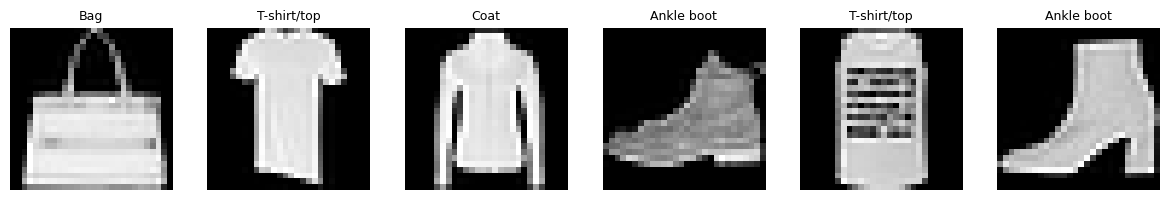

In [33]:
# quick peek at a batch
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axes):
    img = images[i].squeeze().numpy() * STD[0] + MEAN[0]
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. CNN Model Architecture
Two conv blocks (Conv2d -> ReLU -> MaxPool2d) followed by two fully connected layers.


In [34]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)   # 28x28 -> 14x14

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)   # 14x14 -> 7x7

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN(num_classes=10).to(device)
print(model)


CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4. Training Loop
Cross-entropy loss, Adam optimizer. Tracks loss/accuracy per epoch for both train and validation sets.


In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 8

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    torch.set_grad_enabled(True)
    return total_loss / total, correct / total

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss {tr_loss:.4f} acc {tr_acc:.4f} "
          f"| val_loss {val_loss:.4f} acc {val_acc:.4f}")


Epoch 01/8 | train_loss 0.4672 acc 0.8332 | val_loss 0.3152 acc 0.8883
Epoch 02/8 | train_loss 0.3038 acc 0.8897 | val_loss 0.2702 acc 0.9017
Epoch 03/8 | train_loss 0.2550 acc 0.9072 | val_loss 0.2318 acc 0.9113
Epoch 04/8 | train_loss 0.2243 acc 0.9188 | val_loss 0.2230 acc 0.9173
Epoch 05/8 | train_loss 0.2000 acc 0.9263 | val_loss 0.2257 acc 0.9158
Epoch 06/8 | train_loss 0.1809 acc 0.9334 | val_loss 0.2251 acc 0.9190
Epoch 07/8 | train_loss 0.1633 acc 0.9395 | val_loss 0.2090 acc 0.9252
Epoch 08/8 | train_loss 0.1465 acc 0.9454 | val_loss 0.2233 acc 0.9212


In [36]:
# Save the trained model's state dict
model_path = os.path.join(model_dir, f"{STUDENT_ID}.pth")
torch.save(model.state_dict(), model_path)
print("Model saved to:", model_path)
print("Remember to git add/commit/push this .pth file to your repo's model/ folder!")


Model saved to: 220129_CNN/model/220129.pth
Remember to git add/commit/push this .pth file to your repo's model/ folder!


## 5. Final Evaluation on Standard Test Set

In [37]:
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


Test Loss: 0.2553 | Test Accuracy: 0.9158


## 6. Training History Plots (Loss & Accuracy vs Epoch)

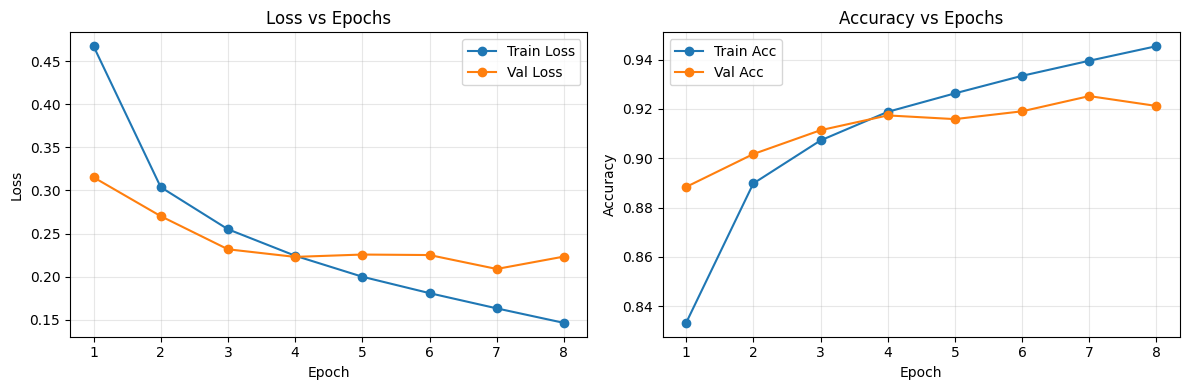

In [38]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("Loss vs Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="Val Acc")
axes[1].set_title("Accuracy vs Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Confusion Matrix (Standard Test Set)

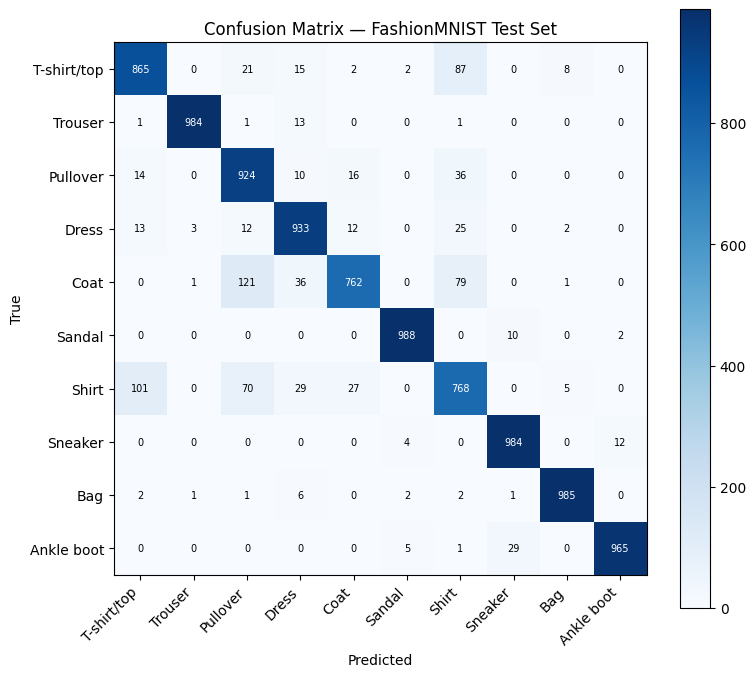

In [39]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — FashionMNIST Test Set")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
plt.colorbar(im)
plt.tight_layout()
plt.show()


## 8. Real-World Prediction — Your 10 Phone Photos
Loads each custom image from your cloned repo's `dataset/` folder, applies the **exact same** transform
pipeline used on training data (grayscale conversion, resize, tensor, normalize), and predicts.

**Note:** phone photos also get auto-inverted (dark bg / light object, matching FashionMNIST) and
center-cropped to square before resizing — otherwise predictions come out wrong even with a well-trained
model. See the fix in the next cell.


In [40]:
def load_and_predict(image_path):
    img_raw = Image.open(image_path).convert("L")   # grayscale, same as FashionMNIST

    # --- FIX 1: auto-invert brightness ---
    # FashionMNIST training images = dark (near-black) background, light garment.
    # A phone photo of a real object on a table/floor is the OPPOSITE (bright background,
    # darker object). Feeding that straight into the model is why real photos were
    # being misclassified even though test accuracy was ~92%. We detect a bright
    # background and invert so it matches the training distribution.
    arr = np.array(img_raw)
    if arr.mean() > 127:
        img_raw = Image.eval(img_raw, lambda x: 255 - x)

    # --- FIX 2: center-crop to square before resizing ---
    # Phone photos are rectangular (e.g. 3024x4032). Resizing straight to 28x28
    # squishes the object out of proportion. Center-crop to a square first so the
    # object's shape is preserved, matching how FashionMNIST items are framed.
    w, h = img_raw.size
    side = min(w, h)
    left, top = (w - side) // 2, (h - side) // 2
    img_raw = img_raw.crop((left, top, left + side, top + side))

    tensor = train_transform(img_raw).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1).squeeze()
        conf, pred_idx = torch.max(probs, dim=0)
    return img_raw, CLASS_NAMES[pred_idx.item()], conf.item() * 100

results = []
for fname in custom_image_files:
    path = os.path.join(dataset_dir, fname)
    img, pred_class, confidence = load_and_predict(path)
    results.append((fname, img, pred_class, confidence))
    print(f"{fname:20s} -> Pred: {pred_class} ({confidence:.1f}%)")


T-shirt.jpeg         -> Pred: T-shirt/top (88.3%)
ankleboot.jpg        -> Pred: Bag (98.2%)
bag.jpeg             -> Pred: Bag (99.6%)
coat.jpg             -> Pred: Coat (37.9%)
dress.jpeg           -> Pred: Bag (38.5%)
pullover.jpg         -> Pred: Bag (99.9%)
sandal.jpeg          -> Pred: T-shirt/top (35.8%)
shirt.jpg            -> Pred: Pullover (72.1%)
sneaker.jpeg         -> Pred: Bag (87.4%)
trouser.jpeg         -> Pred: Trouser (100.0%)


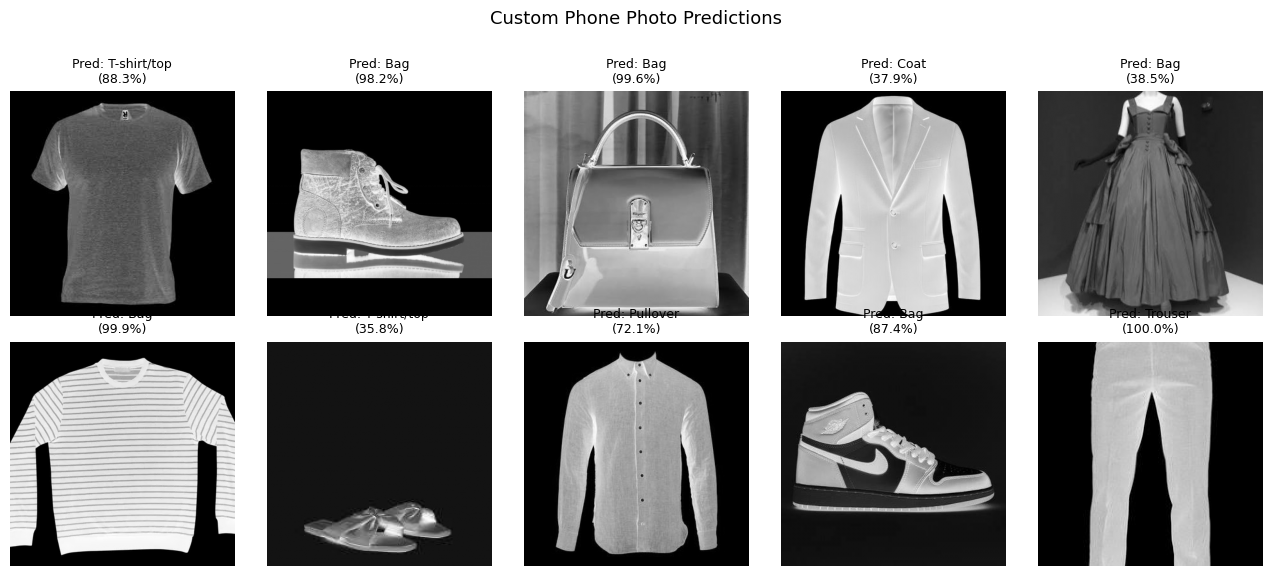

In [41]:
# Custom Prediction Gallery
n = len(results)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.8))
axes = np.array(axes).reshape(-1)

for i, (fname, img, pred_class, confidence) in enumerate(results):
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Pred: {pred_class}\n({confidence:.1f}%)", fontsize=9)
    axes[i].axis("off")

for j in range(len(results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Custom Phone Photo Predictions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 9. Visual Error Analysis — Misclassified Test Images

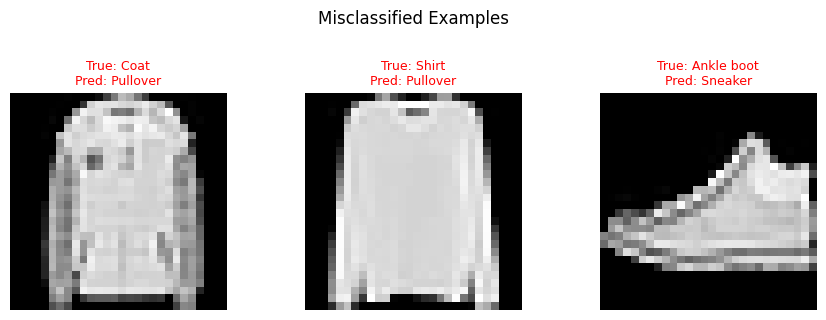

In [42]:
all_labels_arr = np.array(all_labels)
all_preds_arr = np.array(all_preds)
wrong_idx = np.where(all_labels_arr != all_preds_arr)[0]

sample_wrong = np.random.choice(wrong_idx, size=min(3, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(1, len(sample_wrong), figsize=(len(sample_wrong) * 3, 3))
if len(sample_wrong) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_wrong):
    img_tensor, true_label = test_set[idx]
    img = img_tensor.squeeze().numpy() * STD[0] + MEAN[0]
    pred_label = all_preds_arr[idx]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}",
                 fontsize=9, color="red")
    ax.axis("off")

plt.suptitle("Misclassified Examples", y=1.05)
plt.tight_layout()
plt.show()


In [44]:
torch.save(model, '220129_CNN.pth')

from google.colab import files
files.download('220129_CNN.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Summary

- Final Test Accuracy: printed above (Section 5)
- Model saved as `model/{STUDENT_ID}.pth`
- Custom phone-photo predictions and confidences: printed in Section 8

### Before you submit, checklist:
- [ ] Set `REPO_URL` and `STUDENT_ID` at the top to your real values
- [ ] Push your 10 real phone photos into `dataset/` in your GitHub repo
- [ ] Run **Runtime → Run all** on a fresh Colab session — confirm it clones, trains, and predicts with zero manual steps
- [ ] Push the generated `{STUDENT_ID}.pth` into `model/`
- [ ] Write your `README.md` with architecture description + these plots
- [ ] Rename this notebook to `{STUDENT_ID}.ipynb` and push it to the repo root
